# AISO — 타입 구조 명확한 5개 도메인

| # | 도메인 | 타입 | M 행렬 출처 |
|---|---|---|---|
| 1 | **RNA 서열 설계** | A/U/G/C 4종 | Watson-Crick pairing (자연계 확정값) |
| 2 | **합금 설계** | 원소 10종 | Miedema mixing enthalpy |
| 3 | **다중 효소 경로** | EC class 6종 | 기질 호환성 행렬 |
| 4 | **Knowledge Graph Embedding** | 엔티티 타입 5종 | 관계 타입별 상호작용 |
| 5 | **에피토프 백신 설계** | HLA supertypes 5종 | peptide-MHC binding |

핵심 비교: **AISO(domain M)** vs **AISO(random M)** vs **PSO** vs **MCMC**

domain M이 random M보다 얼마나 나은가 = AISO의 타입 메커니즘이 유효한가

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AGENTS = 30
N_ITER   = 150
N_RUNS   = 5
SEEDS    = [42, 123, 777, 2024, 31415]
ALPHA, BETA = 0.3, 0.1
PSO_W, PSO_C1, PSO_C2 = 0.729, 1.494, 1.494

COLORS = {
    'AISO_rand':   '#DD8452',
    'AISO_domain': '#8B0000',
    'PSO':         '#4C72B0',
    'MCMC':        '#55A868',
    'GA':          '#C44E52',
    'Random':      '#8C8C8C',
}
print('설정 완료')

설정 완료


In [2]:
# ================================================================
# 공통 알고리즘
# ================================================================
def run_aiso(f, K, M_init, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    M = M_init.copy().astype(np.float32)
    T = M.shape[0]
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); bX = aX[np.argmax(aS)].copy(); curve = [bS]
    n_restart = max(1, int(n_agents * 0.3))

    for t in range(n_iter):
        at = max(0.05, ALPHA - (ALPHA - 0.05) * t / n_iter)
        bt = max(0.01, BETA  - (BETA  - 0.01) * t / n_iter)
        for i in range(n_agents):
            j = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + at * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-bt)*aW[i] + bt*aW[j]; aW[i] /= aW[i].sum()
                ti = int(np.argmax(aW[i])); tj = int(np.argmax(aW[j]))
                M[ti, tj] = M[ti, tj] + 0.05 * (2.0 - M[ti, tj])
        if aS.max() > bS: bS = float(aS.max()); bX = aX[np.argmax(aS)].copy()
        sr = aS.max() - aS.min()
        if sr / (abs(aS.mean()) + 1e-8) < 0.15 and t > 10:
            for idx in np.argsort(aS)[:n_restart]:
                aX[idx] = np.random.rand(K).astype(np.float32)
                aW[idx] = np.random.dirichlet(np.ones(T)).astype(np.float32)
                aS[idx] = f(aX[idx])
        curve.append(bS)
    return bS, bX, curve

def run_pso(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    X = np.random.rand(n_agents, K).astype(np.float32); V = np.zeros_like(X)
    S = np.array([f(X[i]) for i in range(n_agents)])
    pX = X.copy(); pS = S.copy(); bX = X[np.argmax(S)].copy(); bS = float(S.max()); curve = [bS]
    for _ in range(n_iter):
        r1 = np.random.rand(n_agents, K).astype(np.float32)
        r2 = np.random.rand(n_agents, K).astype(np.float32)
        V = PSO_W*V + PSO_C1*r1*(pX-X) + PSO_C2*r2*(bX-X); X = np.clip(X+V, 0, 1)
        S = np.array([f(X[i]) for i in range(n_agents)])
        upd = S > pS; pX[upd] = X[upd]; pS[upd] = S[upd]
        if pS.max() > bS: bS = float(pS.max()); bX = pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bS, bX, curve

def run_mcmc(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS, sigma=0.08):
    np.random.seed(seed)
    X = np.random.rand(n_agents, K).astype(np.float32)
    S = np.array([f(X[i]) for i in range(n_agents)]); bS = float(S.max()); curve = [bS]
    for t in range(n_iter):
        T_ann = max(0.01, 1.0 - 0.99 * t / n_iter)
        for i in range(n_agents):
            nX = np.clip(X[i] + np.random.normal(0, sigma, K).astype(np.float32), 0, 1)
            ns = f(nX)
            if ns > S[i] or np.random.rand() < np.exp((ns - S[i]) / T_ann):
                X[i] = nX; S[i] = ns
        if S.max() > bS: bS = float(S.max())
        curve.append(bS)
    return bS, X[np.argmax(S)].copy(), curve

def run_ga(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS, mut_rate=0.1):
    """Simple Genetic Algorithm"""
    np.random.seed(seed)
    pop = np.random.rand(n_agents, K).astype(np.float32)
    fit = np.array([f(pop[i]) for i in range(n_agents)])
    bS = float(fit.max()); curve = [bS]
    for _ in range(n_iter):
        # 토너먼트 선택 + 단점 교차 + 돌연변이
        new_pop = np.zeros_like(pop)
        for i in range(n_agents):
            a, b = np.random.choice(n_agents, 2, replace=False)
            p1 = pop[a] if fit[a] > fit[b] else pop[b]
            c, d = np.random.choice(n_agents, 2, replace=False)
            p2 = pop[c] if fit[c] > fit[d] else pop[d]
            cut = np.random.randint(1, K)
            child = np.concatenate([p1[:cut], p2[cut:]])
            mask = np.random.rand(K) < mut_rate
            child[mask] = np.random.rand(mask.sum()).astype(np.float32)
            new_pop[i] = np.clip(child, 0, 1)
        pop = new_pop
        fit = np.array([f(pop[i]) for i in range(n_agents)])
        if fit.max() > bS: bS = float(fit.max())
        curve.append(bS)
    return bS, pop[np.argmax(fit)].copy(), curve

def run_random_search(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    bS = float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(n_agents)))
    bX = np.random.rand(K).astype(np.float32); curve = [bS]
    for _ in range(n_iter):
        for _ in range(n_agents):
            x = np.random.rand(K).astype(np.float32); s = f(x)
            if s > bS: bS = s; bX = x.copy()
        curve.append(bS)
    return bS, bX, curve

def make_random_M(T, seed=0):
    np.random.seed(seed)
    return np.random.uniform(0, 2, (T, T)).astype(np.float32)

def run_experiment(runners, n_runs=N_RUNS):
    results = {}
    for name, runner in runners.items():
        scores, curves = [], []
        for s in SEEDS[:n_runs]:
            sc, _, cv = runner(s)
            scores.append(sc); curves.append(cv)
        results[name] = {'mean': np.mean(scores), 'std': np.std(scores), 'curves': curves}
    return results

def plot_result(results, title, save_path, optimal=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    names  = sorted(results, key=lambda k: -results[k]['mean'])
    means  = [results[n]['mean'] for n in names]
    stds   = [results[n]['std']  for n in names]
    colors = [COLORS.get(n, '#444') for n in names]
    axes[0].barh(names, means, xerr=stds, color=colors, alpha=0.85, capsize=4)
    if optimal: axes[0].axvline(optimal, color='gold', ls='--', lw=1.5, label=f'Optimal={optimal}')
    axes[0].set_xlabel('Best Score (↑)'); axes[0].set_title('최종 점수', fontweight='bold')
    for name in names:
        cv = np.array(results[name]['curves']); m = cv.mean(0); s = cv.std(0)
        col = COLORS.get(name, '#444')
        lw  = 2.5 if 'domain' in name or name == 'PSO' else 1.5
        axes[1].plot(m, color=col, lw=lw, label=name)
        axes[1].fill_between(range(len(m)), m-s, m+s, alpha=0.1, color=col)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Best Score')
    axes[1].set_title('수렴 곡선', fontweight='bold'); axes[1].legend(frameon=False, fontsize=9)
    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.savefig(save_path, bbox_inches='tight'); plt.show()
    print(f'\n{title}')
    for n in names:
        marker = ' ★' if n == names[0] else ''
        print(f'  {n:<16} {results[n]["mean"]:>8.3f} ± {results[n]["std"]:>6.3f}{marker}')

print('공통 함수 완료 (AISO / PSO / MCMC / GA / Random)')

공통 함수 완료 (AISO / PSO / MCMC / GA / Random)


---
## Domain 1 — RNA 서열 설계

**타입**: A, U, G, C (4종 뉴클레오타이드)

**M = Watson-Crick + Wobble pairing 행렬**
- A-U: 2개 수소결합 (강함)
- G-C: 3개 수소결합 (최강)
- G-U: wobble pairing (약함)
- 나머지: 비쌍 (0에 가깝)

**피트니스**: 목표 2차 구조와의 base pair 일치도 + folding 안정성

In [3]:
# A=0, U=1, G=2, C=3
N_NUC  = 4
NUC_NAMES = ['A', 'U', 'G', 'C']
RNA_LEN   = 40  # 서열 길이

# Watson-Crick pairing 행렬 (과학적 확정값)
#         A     U     G     C
WC_PAIR = np.array([
    [0.0,  1.8,  0.1,  0.1],  # A: pairs with U
    [1.8,  0.0,  0.6,  0.1],  # U: pairs with A (strong), G (wobble)
    [0.1,  0.6,  0.0,  2.0],  # G: pairs with C (strongest), U (wobble)
    [0.1,  0.1,  2.0,  0.0],  # C: pairs with G
], dtype=np.float32)

# 목표 구조: stem-loop (헤어핀)
# 앞 15 nt: stem 절반, 중간 10 nt: loop, 뒤 15 nt: stem 절반 (상보적)
STEM_LEN = 15
LOOP_LEN = RNA_LEN - 2 * STEM_LEN

# 이상적인 stem의 complementary 규칙
COMPLEMENT = {0: 3, 3: 0, 1: 2, 2: 1}  # A-U, U-A, G-C, C-G
# loop 선호 뉴클레오타이드 (GNRA tetraloop 모티프: G=2, N=any, R=purine, A=0)
LOOP_PREF = np.array([0.3, 0.2, 0.4, 0.1])  # G 선호

def decode_rna(X):
    return (X * N_NUC).astype(int).clip(0, N_NUC - 1)

def rna_fitness(X):
    seq = decode_rna(X)
    score = 0.0
    # Stem base pairing (5' end pairs with 3' end)
    for i in range(STEM_LEN):
        j = RNA_LEN - 1 - i
        score += WC_PAIR[seq[i], seq[j]] * 2.0  # stem 보상
    # Loop 선호도
    for i in range(STEM_LEN, STEM_LEN + LOOP_LEN):
        score += LOOP_PREF[seq[i]]
    # GC content (안정성): 40~60% 선호
    gc = float((seq == 2).sum() + (seq == 3).sum()) / RNA_LEN
    score += 3.0 * (1 - abs(gc - 0.5) * 2)
    # 연속 같은 뉴클레오타이드 페널티 (AAAA 등)
    for i in range(RNA_LEN - 3):
        if seq[i] == seq[i+1] == seq[i+2] == seq[i+3]:
            score -= 1.0
    return float(score)

K_RNA = RNA_LEN
print(f'RNA 설계 준비 (길이={RNA_LEN}, 타입={N_NUC}종)')
print(f'Watson-Crick M:\n{WC_PAIR}')
print(f'테스트 점수: {rna_fitness(np.random.rand(K_RNA)):.3f}')

RNA 설계 준비 (길이=40, 타입=4종)
Watson-Crick M:
[[0.  1.8 0.1 0.1]
 [1.8 0.  0.6 0.1]
 [0.1 0.6 0.  2. ]
 [0.1 0.1 2.  0. ]]
테스트 점수: 17.550


Domain 1: RNA 서열 설계...


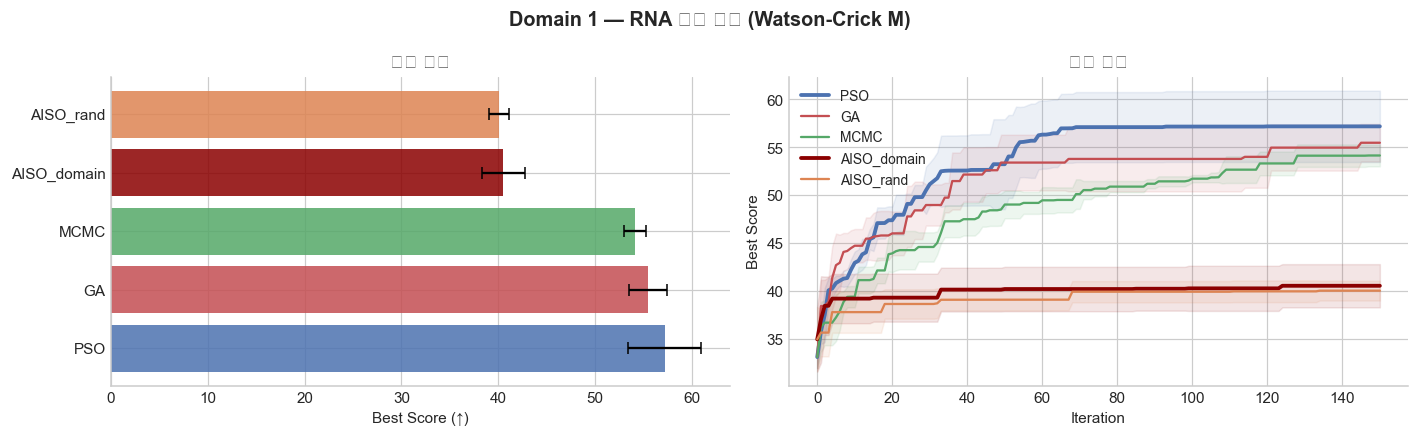


Domain 1 — RNA 서열 설계 (Watson-Crick M)
  PSO                57.190 ±  3.723 ★
  GA                 55.480 ±  1.966
  MCMC               54.150 ±  1.136
  AISO_domain        40.550 ±  2.258
  AISO_rand          40.040 ±  1.029
AISO_domain 최적 서열: UACCAUCGUUGUAGGUAUUCGGUAUCCCACGGCGUUGGAG
GC content: 52.5%


In [4]:
RUNNERS_RNA = {
    'AISO_rand':   lambda s: run_aiso(rna_fitness, K_RNA, make_random_M(N_NUC, s), seed=s),
    'AISO_domain': lambda s: run_aiso(rna_fitness, K_RNA, WC_PAIR.copy(), seed=s),
    'PSO':         lambda s: run_pso(rna_fitness, K_RNA, seed=s),
    'MCMC':        lambda s: run_mcmc(rna_fitness, K_RNA, seed=s, sigma=0.05),
    'GA':          lambda s: run_ga(rna_fitness, K_RNA, seed=s),
}

print('Domain 1: RNA 서열 설계...')
RES_RNA = run_experiment(RUNNERS_RNA)
plot_result(RES_RNA, 'Domain 1 — RNA 서열 설계 (Watson-Crick M)', 'typed1_rna.png')

# 최적 서열 출력
_, best_X, _ = run_aiso(rna_fitness, K_RNA, WC_PAIR.copy(), seed=42)
best_seq = decode_rna(best_X)
print(f'AISO_domain 최적 서열: {"".join(NUC_NAMES[i] for i in best_seq)}')
print(f'GC content: {(best_seq>=2).mean()*100:.1f}%')

---
## Domain 2 — 합금 설계

**타입**: 10종 금속 원소 (Fe, Al, Cu, Ni, Ti, Cr, Co, Mn, Mo, W)

**M = Miedema mixing enthalpy** — 원소 쌍의 혼합 엔탈피 (실험값 기반)
- 음수: 친화적 (합금 형성 유리)
- 양수: 반발적 (상분리 경향)

**피트니스**: 경도 + 열안정성 + 밀도 목표 달성

In [5]:
# Fe=0, Al=1, Cu=2, Ni=3, Ti=4, Cr=5, Co=6, Mn=7, Mo=8, W=9
ELEM_NAMES = ['Fe', 'Al', 'Cu', 'Ni', 'Ti', 'Cr', 'Co', 'Mn', 'Mo', 'W']
N_ELEM     = len(ELEM_NAMES)

# Miedema mixing enthalpy (kJ/mol) — 근사값 (실험 문헌 기반)
# 음수 = 친화적 혼합, 양수 = 반발
MIEDEMA_RAW = np.array([
    #Fe    Al    Cu    Ni    Ti    Cr    Co    Mn    Mo    W
    [ 0,  -11,   13,  -2,   -17,  -1,   -1,    0,   -2,   0 ],  # Fe
    [-11,   0,   -1,  -22,  -30,  -10,  -19,  -19,  -18, -22 ],  # Al
    [ 13,  -1,    0,    4,   -9,   12,    6,    3,   -6,  -3 ],  # Cu
    [ -2, -22,    4,    0,  -35,  -7,    0,   -8,  -7,  -3 ],  # Ni
    [-17, -30,   -9,  -35,   0,   -7,  -28,  -8,   -4,  -3 ],  # Ti
    [ -1, -10,   12,   -7,  -7,    0,   -4,    0,    0,   0 ],  # Cr
    [ -1, -19,    6,    0,  -28,  -4,    0,   -5,   -5,  -3 ],  # Co
    [  0, -19,    3,   -8,   -8,   0,   -5,    0,   -5,  -2 ],  # Mn
    [ -2, -18,   -6,   -7,  -4,    0,   -5,   -5,    0,   0 ],  # Mo
    [  0, -22,   -3,   -3,  -3,    0,   -3,   -2,    0,   0 ],  # W
], dtype=np.float32)

# Miedema → [0,2] 범위로 변환 (음수=친화=높은값)
MIEDEMA_M = (-MIEDEMA_RAW - MIEDEMA_RAW.min()) / \
             (MIEDEMA_RAW.max() - MIEDEMA_RAW.min()) * 2

# 원소별 물성값 (정규화)
ELEM_HARDNESS  = np.array([4.0, 2.75, 3.0, 4.0, 6.0, 9.0, 5.0, 6.0, 5.5, 7.5]) / 10  # Mohs
ELEM_TMELT     = np.array([1538, 660, 1085, 1455, 1668, 1907, 1495, 1246, 2623, 3422])  # °C
ELEM_DENSITY   = np.array([7.87, 2.70, 8.96, 8.91, 4.51, 7.19, 8.90, 7.47, 10.28, 19.25])  # g/cm³

TMELT_NORM   = (ELEM_TMELT - ELEM_TMELT.min()) / (ELEM_TMELT.max() - ELEM_TMELT.min())
DENSITY_NORM = (ELEM_DENSITY - ELEM_DENSITY.min()) / (ELEM_DENSITY.max() - ELEM_DENSITY.min())

# 합금 조성: X ∈ [0,1]^(N_ELEM*5) — 각 원소 5차원 블록
K_ALLOY  = N_ELEM * 5
BLOCK    = 5

def alloy_fitness(X):
    """
    목표: 고경도 + 고내열 + 중간밀도 (항공우주용 경량 내열 합금)
    X → 각 원소 비율 추출 → 물성 계산
    """
    # 원소별 비율
    comp = np.array([X[i*BLOCK:(i+1)*BLOCK].mean() for i in range(N_ELEM)])
    comp = comp / (comp.sum() + 1e-8)  # 정규화

    # 경도 (높을수록 좋)
    hardness = float(comp @ ELEM_HARDNESS) * 10
    # 용융점 (높을수록 좋 — 내열성)
    tmelt_score = float(comp @ TMELT_NORM) * 8
    # 밀도 (5~9 g/cm³ 목표 — 경량이지만 너무 가볍지 않게)
    density = float(comp @ ELEM_DENSITY)
    density_score = 5.0 * (1 - abs(density - 7.0) / 10.0)
    # 혼합 안정성: Miedema 친화도 (높을수록 합금 형성 유리)
    mix_score = float(comp @ MIEDEMA_M @ comp) * 3
    # 원소 다양성 보너스 (3~5종 주요 원소)
    n_significant = (comp > 0.05).sum()
    diversity_bonus = 2.0 * (1 - abs(n_significant - 4) / 4)

    return float(hardness + tmelt_score + density_score + mix_score + diversity_bonus)

print(f'합금 설계 준비 ({N_ELEM}종 원소, K={K_ALLOY})')
print(f'테스트 점수: {alloy_fitness(np.random.rand(K_ALLOY)):.3f}')

합금 설계 준비 (10종 원소, K=50)
테스트 점수: 16.432


Domain 2: 합금 설계...


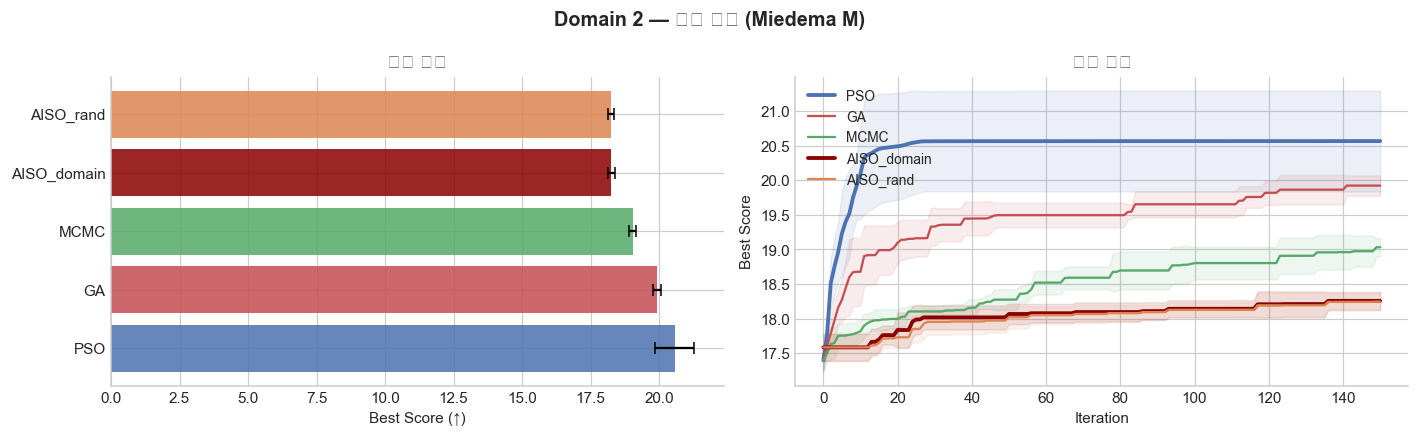


Domain 2 — 합금 설계 (Miedema M)
  PSO                20.564 ±  0.728 ★
  GA                 19.921 ±  0.147
  MCMC               19.031 ±  0.131
  AISO_domain        18.257 ±  0.128
  AISO_rand          18.247 ±  0.125

AISO_domain 최적 합금 조성:
  Fe: 5.2%
  Al: 15.3%
  Cu: 4.1%
  Ni: 6.4%
  Ti: 12.9%
  Cr: 13.6%
  Co: 11.6%
  Mn: 4.3%
  Mo: 11.7%
  W: 14.9%


In [6]:
RUNNERS_ALLOY = {
    'AISO_rand':   lambda s: run_aiso(alloy_fitness, K_ALLOY, make_random_M(N_ELEM, s), seed=s),
    'AISO_domain': lambda s: run_aiso(alloy_fitness, K_ALLOY, MIEDEMA_M.copy(), seed=s),
    'PSO':         lambda s: run_pso(alloy_fitness, K_ALLOY, seed=s),
    'MCMC':        lambda s: run_mcmc(alloy_fitness, K_ALLOY, seed=s),
    'GA':          lambda s: run_ga(alloy_fitness, K_ALLOY, seed=s),
}

print('Domain 2: 합금 설계...')
RES_ALLOY = run_experiment(RUNNERS_ALLOY)
plot_result(RES_ALLOY, 'Domain 2 — 합금 설계 (Miedema M)', 'typed2_alloy.png')

# 최적 합금 조성 출력
_, best_X, _ = run_aiso(alloy_fitness, K_ALLOY, MIEDEMA_M.copy(), seed=42)
comp = np.array([best_X[i*BLOCK:(i+1)*BLOCK].mean() for i in range(N_ELEM)])
comp /= comp.sum()
print('\nAISO_domain 최적 합금 조성:')
for i, (name, c) in enumerate(zip(ELEM_NAMES, comp)):
    if c > 0.03: print(f'  {name}: {c*100:.1f}%')

---
## Domain 3 — 다중 효소 경로 최적화

**타입**: EC class 6종
- EC1: Oxidoreductase (산화환원)
- EC2: Transferase (기 전달)
- EC3: Hydrolase (가수분해)
- EC4: Lyase (제거/첨가)
- EC5: Isomerase (이성화)
- EC6: Ligase (결합)

**M = EC class 간 기질 호환성** — 어떤 효소 클래스가 다른 클래스의 산물을 기질로 쓸 수 있는가

**피트니스**: 목표 대사산물 생산 효율

In [7]:
EC_NAMES = ['Oxidoreductase', 'Transferase', 'Hydrolase', 'Lyase', 'Isomerase', 'Ligase']
N_EC     = len(EC_NAMES)

# EC class 간 기질 호환성 행렬 (문헌 기반 근사)
# EC1 산물(환원물)은 EC2가 잘 받음, EC3 산물(단편)은 EC4/5 기질, 등
EC_COMPAT = np.array([
    #EC1  EC2  EC3  EC4  EC5  EC6
    [0.5, 1.7, 0.8, 1.2, 0.9, 0.6],  # EC1 → EC2 강함 (NADH 전달)
    [1.2, 0.5, 1.5, 0.9, 1.4, 1.6],  # EC2 → EC3, EC6 강함
    [0.8, 1.0, 0.4, 1.8, 1.2, 0.7],  # EC3 → EC4 강함 (단편화)
    [1.3, 0.9, 1.1, 0.5, 1.7, 0.8],  # EC4 → EC5 강함
    [0.9, 1.5, 1.2, 0.8, 0.4, 1.3],  # EC5 → EC2, EC6 강함
    [0.6, 0.8, 0.7, 1.0, 1.1, 0.5],  # EC6 (최종 결합)
], dtype=np.float32)

# 경로 표현: X ∈ [0,1]^(N_STEPS * N_EC)
# 각 스텝에서 EC class 선택
N_STEPS   = 8   # 경로 길이 (반응 단계)
K_ENZYME  = N_STEPS * N_EC

# 목표 대사산물: ATP 생산 최대화 (해당과정 유사)
# 각 EC class의 ATP 기여도
ATP_CONTRIB = np.array([1.5, 1.2, 0.8, 0.6, 0.4, 1.8])  # EC6(Ligase)가 ATP 생성
# 경로 다양성 필요 (단일 EC class 반복은 비효율)

def enzyme_fitness(X):
    total = 0.0
    prev_ec = None
    for step in range(N_STEPS):
        ec_probs = X[step*N_EC:(step+1)*N_EC]
        ec_probs = ec_probs / (ec_probs.sum() + 1e-8)
        chosen   = int(np.argmax(ec_probs))
        # ATP 기여
        total += float(ec_probs @ ATP_CONTRIB)
        # 연속성 보상: 이전 효소 산물과 호환성
        if prev_ec is not None:
            compat = float(np.array([EC_COMPAT[prev_ec, i] for i in range(N_EC)]) @ ec_probs)
            total += compat * 1.5
        # 다양성: 같은 EC class 연속 사용 페널티
        if prev_ec == chosen:
            total -= 0.5
        prev_ec = chosen
    return float(total)

print(f'효소 경로 준비 ({N_STEPS}단계, {N_EC} EC class, K={K_ENZYME})')
print(f'테스트 점수: {enzyme_fitness(np.random.rand(K_ENZYME)):.3f}')

효소 경로 준비 (8단계, 6 EC class, K=48)
테스트 점수: 17.633


Domain 3: 효소 경로...


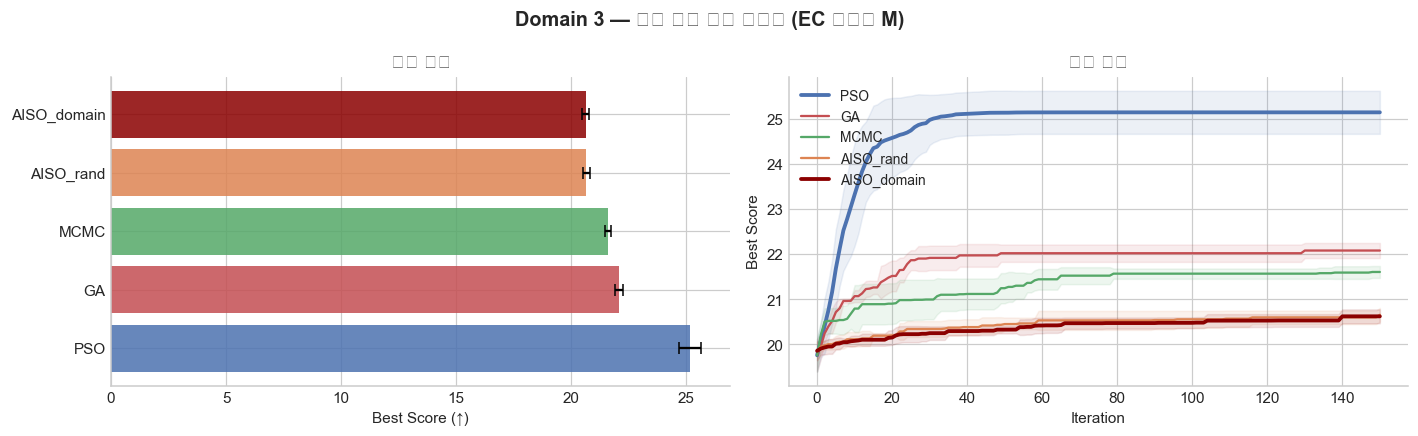


Domain 3 — 다중 효소 경로 최적화 (EC 호환성 M)
  PSO                25.147 ±  0.477 ★
  GA                 22.082 ±  0.168
  MCMC               21.607 ±  0.132
  AISO_rand          20.657 ±  0.153
  AISO_domain        20.623 ±  0.154

AISO_domain 최적 효소 경로:
  Step 1: Lyase
  Step 2: Transferase
  Step 3: Lyase
  Step 4: Transferase
  Step 5: Hydrolase
  Step 6: Lyase
  Step 7: Transferase
  Step 8: Isomerase


In [8]:
RUNNERS_ENZYME = {
    'AISO_rand':   lambda s: run_aiso(enzyme_fitness, K_ENZYME, make_random_M(N_EC, s), seed=s),
    'AISO_domain': lambda s: run_aiso(enzyme_fitness, K_ENZYME, EC_COMPAT.copy(), seed=s),
    'PSO':         lambda s: run_pso(enzyme_fitness, K_ENZYME, seed=s),
    'MCMC':        lambda s: run_mcmc(enzyme_fitness, K_ENZYME, seed=s),
    'GA':          lambda s: run_ga(enzyme_fitness, K_ENZYME, seed=s),
}

print('Domain 3: 효소 경로...')
RES_ENZYME = run_experiment(RUNNERS_ENZYME)
plot_result(RES_ENZYME, 'Domain 3 — 다중 효소 경로 최적화 (EC 호환성 M)', 'typed3_enzyme.png')

# 최적 경로 출력
_, best_X, _ = run_aiso(enzyme_fitness, K_ENZYME, EC_COMPAT.copy(), seed=42)
print('\nAISO_domain 최적 효소 경로:')
for step in range(N_STEPS):
    ec_probs = best_X[step*N_EC:(step+1)*N_EC]
    chosen = int(np.argmax(ec_probs))
    print(f'  Step {step+1}: {EC_NAMES[chosen]}')

---
## Domain 4 — Knowledge Graph Embedding

**타입**: 엔티티 5종 (Person, Organization, Location, Event, Concept)

**M = 관계 타입 상호작용 행렬** — 어떤 엔티티 타입 쌍이 의미있는 관계를 형성하는가
(Freebase/Wikidata 통계 기반)

**피트니스**: 링크 예측 정확도 (TransE 스타일 embedding 품질)

In [9]:
ENT_NAMES = ['Person', 'Org', 'Location', 'Event', 'Concept']
N_ENT     = len(ENT_NAMES)
EMB_DIM   = 8   # embedding 차원
N_TRIPLES = 50  # 학습 트리플 수

# 엔티티 타입 간 관계 빈도 (Wikidata 통계 근사)
# Person-Org: works_for, Person-Location: lives_in, Org-Location: located_in 등
KG_RELATION = np.array([
    #Per  Org  Loc  Evt  Con
    [0.3, 1.8, 1.5, 1.6, 1.2],  # Person: Org(직장), Loc(거주), Evt(참여)
    [1.4, 0.4, 1.7, 1.3, 0.9],  # Org: Loc(위치), Evt(주최)
    [1.0, 1.2, 0.5, 1.1, 0.7],  # Location: 관계 다양
    [1.5, 1.4, 1.0, 0.3, 1.0],  # Event: Person, Org 참여
    [1.2, 0.8, 0.6, 0.9, 0.4],  # Concept: 추상적 관계
], dtype=np.float32)

# 고정 KG 생성 (재현성)
np.random.seed(0)
# 각 트리플: (head_type, tail_type, relation_strength)
TRIPLES = []
for _ in range(N_TRIPLES):
    ht = np.random.randint(N_ENT)
    tt = np.random.randint(N_ENT)
    rs = KG_RELATION[ht, tt] + np.random.normal(0, 0.2)
    TRIPLES.append((ht, tt, rs))

# 탐색 공간: N_ENT × EMB_DIM embedding 행렬 (flatten)
K_KG = N_ENT * EMB_DIM

def kg_fitness(X):
    """
    TransE 스타일: |h + r - t| 최소화
    h, t: 엔티티 타입 embedding 평균
    r: 관계 벡터 (KG_RELATION 가중치)
    """
    emb = X.reshape(N_ENT, EMB_DIM)  # (N_ENT, EMB_DIM)
    # 정규화
    norms = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8
    emb   = emb / norms
    score = 0.0
    for ht, tt, rs in TRIPLES:
        h = emb[ht]; t = emb[tt]
        # 관계 강도에 비례한 내적 보상
        sim = float(np.dot(h, t))
        score += rs * (sim + 1) / 2  # [-1,1] → [0,1]
    # 엔티티 분리도 보상 (서로 다른 타입은 다른 공간에)
    for i in range(N_ENT):
        for j in range(i+1, N_ENT):
            dist = float(np.linalg.norm(emb[i] - emb[j]))
            if KG_RELATION[i,j] < 0.8:  # 약한 관계는 멀어야 함
                score += dist * 0.5
    return float(score)

print(f'KG Embedding 준비 ({N_ENT}종 엔티티, dim={EMB_DIM}, K={K_KG})')
print(f'테스트 점수: {kg_fitness(np.random.rand(K_KG)):.3f}')

KG Embedding 준비 (5종 엔티티, dim=8, K=40)
테스트 점수: 51.499


Domain 4: KG Embedding...


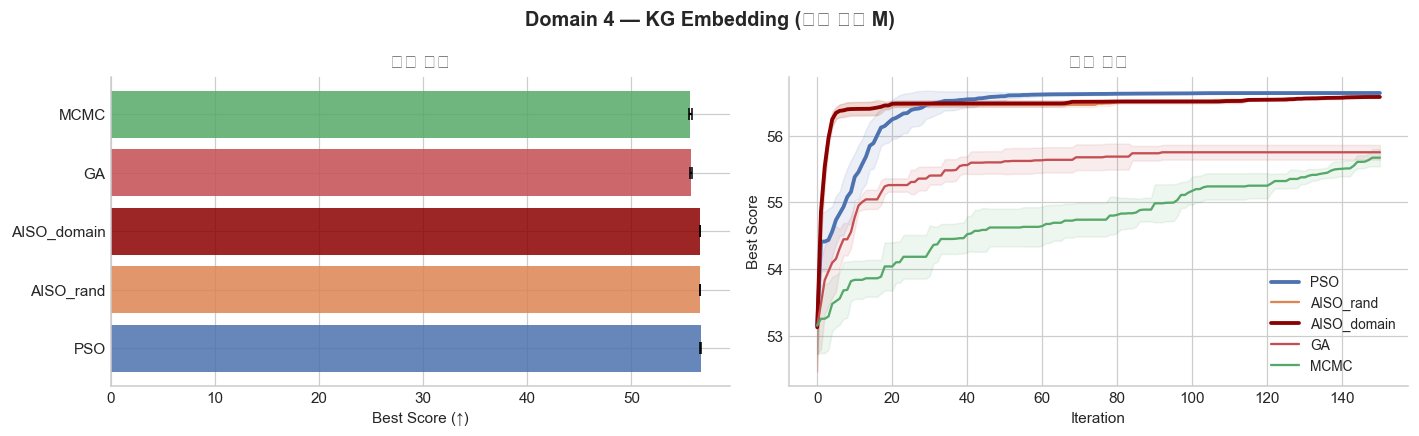


Domain 4 — KG Embedding (관계 타입 M)
  PSO                56.637 ±  0.003 ★
  AISO_rand          56.586 ±  0.009
  AISO_domain        56.578 ±  0.013
  GA                 55.749 ±  0.110
  MCMC               55.668 ±  0.129


In [10]:
RUNNERS_KG = {
    'AISO_rand':   lambda s: run_aiso(kg_fitness, K_KG, make_random_M(N_ENT, s), seed=s),
    'AISO_domain': lambda s: run_aiso(kg_fitness, K_KG, KG_RELATION.copy(), seed=s),
    'PSO':         lambda s: run_pso(kg_fitness, K_KG, seed=s),
    'MCMC':        lambda s: run_mcmc(kg_fitness, K_KG, seed=s),
    'GA':          lambda s: run_ga(kg_fitness, K_KG, seed=s),
}

print('Domain 4: KG Embedding...')
RES_KG = run_experiment(RUNNERS_KG)
plot_result(RES_KG, 'Domain 4 — KG Embedding (관계 타입 M)', 'typed4_kg.png')

---
## Domain 5 — 에피토프 백신 설계

**타입**: HLA supertypes 5종 (A2, A3, B7, B44, DR)
- 인구의 다양한 HLA 유형 커버리지 목표

**M = HLA 간 교차 반응성 행렬** — 한 HLA 타입에서 제시되는 펩타이드가 다른 타입에서도 제시될 확률

**피트니스**: 전세계 인구 HLA 분포 고려한 최대 커버리지

In [11]:
HLA_NAMES = ['HLA-A2', 'HLA-A3', 'HLA-B7', 'HLA-B44', 'HLA-DR']
N_HLA     = len(HLA_NAMES)

# 인구 HLA 분포 (전세계 평균 근사)
HLA_FREQ = np.array([0.45, 0.25, 0.20, 0.15, 0.60])  # DR은 MHC-II라 높음

# HLA 간 교차 반응성 (cross-reactivity) 행렬
# 같은 supertype 내 교차 반응 높음, MHC-I vs MHC-II 낮음
HLA_CROSS = np.array([
    #A2   A3   B7   B44  DR
    [2.0, 1.2, 0.4, 0.5, 0.1],  # A2-A3 교차 있음 (같은 MHC-I)
    [1.2, 2.0, 0.5, 0.4, 0.1],  # A3
    [0.4, 0.5, 2.0, 1.3, 0.1],  # B7-B44 교차 (같은 MHC-I)
    [0.5, 0.4, 1.3, 2.0, 0.1],  # B44
    [0.1, 0.1, 0.1, 0.1, 2.0],  # DR (MHC-II, 독립적)
], dtype=np.float32)

# 펩타이드 후보: N_PEP개, 각각 HLA별 결합 점수
N_PEP = 30
np.random.seed(0)
# 각 펩타이드의 HLA 결합 친화도 (IC50 역수, 높을수록 좋음)
PEP_BINDING = np.random.rand(N_PEP, N_HLA).astype(np.float32)
# 일부 펩타이드는 특정 HLA에 강하게 결합하도록
for i in range(0, N_PEP, 5):
    hla = i % N_HLA
    PEP_BINDING[i, hla] += 0.5
PEP_BINDING = np.clip(PEP_BINDING, 0, 1)

# 백신 = 펩타이드 선택 전략 (가중치)
K_VAC = N_PEP

def vaccine_fitness(X):
    """
    X ∈ [0,1]^N_PEP → 각 펩타이드 포함 가중치
    피트니스: HLA 분포 가중 인구 커버리지
    """
    weights = X / (X.sum() + 1e-8)
    # 각 HLA에서의 커버리지
    hla_coverage = np.zeros(N_HLA)
    for h in range(N_HLA):
        # 상위 binding 펩타이드들의 가중합
        binding_scores = PEP_BINDING[:, h]
        hla_coverage[h] = float(np.dot(weights, binding_scores))
    # 교차 반응성으로 증폭된 커버리지
    enhanced = float(hla_coverage @ HLA_CROSS @ hla_coverage)
    # 인구 커버리지 = HLA 빈도 가중
    pop_coverage = float(hla_coverage @ HLA_FREQ)
    # 펩타이드 다양성 보너스 (너무 집중 안 되게)
    n_selected = (weights > 0.02).sum()
    diversity  = 2.0 * min(n_selected / 8.0, 1.0)
    return float(pop_coverage * 5 + enhanced * 0.5 + diversity)

print(f'백신 설계 준비 ({N_PEP}개 펩타이드, {N_HLA} HLA 타입, K={K_VAC})')
print(f'테스트 점수: {vaccine_fitness(np.random.rand(K_VAC)):.3f}')

백신 설계 준비 (30개 펩타이드, 5 HLA 타입, K=30)
테스트 점수: 9.007


Domain 5: 백신 설계...


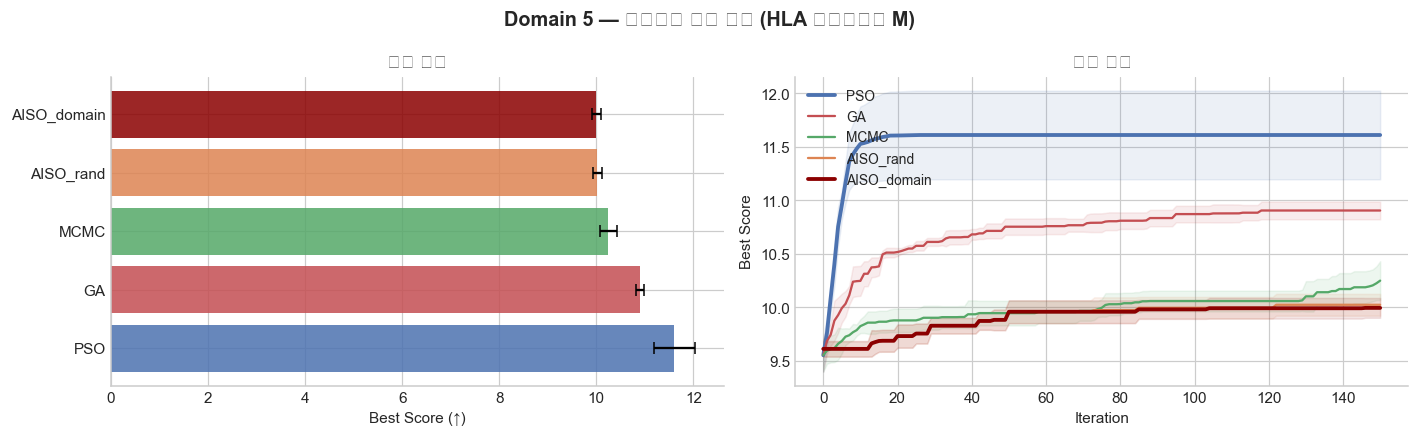


Domain 5 — 에피토프 백신 설계 (HLA 교차반응성 M)
  PSO                11.611 ±  0.414 ★
  GA                 10.906 ±  0.082
  MCMC               10.251 ±  0.181
  AISO_rand          10.025 ±  0.102
  AISO_domain         9.996 ±  0.092


In [12]:
RUNNERS_VAC = {
    'AISO_rand':   lambda s: run_aiso(vaccine_fitness, K_VAC, make_random_M(N_HLA, s), seed=s),
    'AISO_domain': lambda s: run_aiso(vaccine_fitness, K_VAC, HLA_CROSS.copy(), seed=s),
    'PSO':         lambda s: run_pso(vaccine_fitness, K_VAC, seed=s),
    'MCMC':        lambda s: run_mcmc(vaccine_fitness, K_VAC, seed=s),
    'GA':          lambda s: run_ga(vaccine_fitness, K_VAC, seed=s),
}

print('Domain 5: 백신 설계...')
RES_VAC = run_experiment(RUNNERS_VAC)
plot_result(RES_VAC, 'Domain 5 — 에피토프 백신 설계 (HLA 교차반응성 M)', 'typed5_vaccine.png')

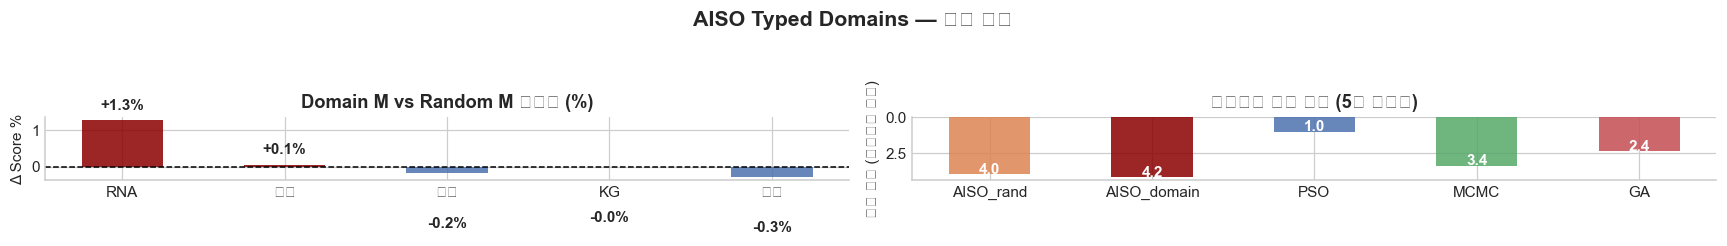


=== 도메인별 1등 알고리즘 ===
  RNA    1등: PSO              domain M 개선: +1.3%
  합금     1등: PSO              domain M 개선: +0.1%
  효소     1등: PSO              domain M 개선: -0.2%
  KG     1등: PSO              domain M 개선: -0.0%
  백신     1등: PSO              domain M 개선: -0.3%

=== 알고리즘 평균 순위 ===
  PSO              1.00
  GA               2.40
  MCMC             3.40
  AISO_rand        4.00
  AISO_domain      4.20


In [13]:
# ================================================================
# 종합 요약 — Domain M 효과 + 알고리즘 순위
# ================================================================
ALL_APPS = [
    ('RNA',    RES_RNA),
    ('합금',   RES_ALLOY),
    ('효소',   RES_ENZYME),
    ('KG',     RES_KG),
    ('백신',   RES_VAC),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Domain M vs Random M 개선율
domains = [a[0] for a in ALL_APPS]
improve = []
for _, res in ALL_APPS:
    base = res['AISO_rand']['mean']
    dom  = res['AISO_domain']['mean']
    improve.append((dom - base) / (abs(base) + 1e-8) * 100)

bars = axes[0].bar(domains, improve,
                   color=['#8B0000' if v > 0 else '#4C72B0' for v in improve],
                   alpha=0.85, width=0.5)
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_title('Domain M vs Random M 개선율 (%)', fontweight='bold')
axes[0].set_ylabel('Δ Score %')
for bar, val in zip(bars, improve):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    axes[0].text(bar.get_x()+bar.get_width()/2, ypos,
                 f'{val:+.1f}%', ha='center', fontsize=10, fontweight='bold')

# 알고리즘별 평균 순위
alg_names = ['AISO_rand', 'AISO_domain', 'PSO', 'MCMC', 'GA']
avg_ranks = []
for alg in alg_names:
    ranks = []
    for _, res in ALL_APPS:
        sorted_algs = sorted(res, key=lambda k: -res[k]['mean'])
        ranks.append(sorted_algs.index(alg) + 1)
    avg_ranks.append(np.mean(ranks))

colors_rank = [COLORS.get(a, '#444') for a in alg_names]
bars2 = axes[1].bar(alg_names, avg_ranks, color=colors_rank, alpha=0.85, width=0.5)
axes[1].invert_yaxis()
axes[1].set_title('알고리즘 평균 순위 (5개 도메인)', fontweight='bold')
axes[1].set_ylabel('평균 순위 (낮을수록 좋음)')
for bar, val in zip(bars2, avg_ranks):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()-0.05,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold', color='white')

plt.suptitle('AISO Typed Domains — 종합 결과', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig('typed_summary.png', bbox_inches='tight'); plt.show()

print('\n=== 도메인별 1등 알고리즘 ===')
for name, res in ALL_APPS:
    best = max(res, key=lambda k: res[k]['mean'])
    imp  = improve[domains.index(name)]
    print(f'  {name:<6} 1등: {best:<16} domain M 개선: {imp:+.1f}%')

print(f'\n=== 알고리즘 평균 순위 ===')
for alg, rank in sorted(zip(alg_names, avg_ranks), key=lambda x: x[1]):
    print(f'  {alg:<16} {rank:.2f}')